## Week 4 :- Exoplanet Detection Project
# Model Mastery & Honest Evaluation
**Author:** Mann
**Date:** April 2026 
**Dataset:** Kepler Labelled Time Series Data

## Week 4 Goals
- Beat 3/5 planet detection from Week 3
- Try CNN + BiLSTM hybrid architecture
- Apply FFT frequency domain features
- Cross-validate across all 37 real planets
- Honestly evaluate model limitations

## Week 3 Recap
| Metric | Value |
|--------|-------|
| val_AUC | 0.9970 |
| Test ROC-AUC | 0.7483 |
| Planets Detected | 3/5 (60%) |
| False Positives | 0 |
| Architecture | 3x Conv1D + BatchNorm + GAP + Dense(32) |

**Key limitation identified:** Only 37 real training planets — 
root cause of all generalization problems.

## 1. Imports & Setup
All libraries, paths, and random seeds fixed here.
Seed = 42 used throughout for reproducibility.

In [1]:
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Input, Conv1D, BatchNormalization,
    MaxPooling1D, Dropout, Dense, LSTM, Bidirectional,
    GlobalAveragePooling1D, Concatenate, Flatten)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import Precision, Recall, AUC
import os

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

C:\Software\anaconda\envs\exoplanet_clean\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


## 2. Load Week 2 Processed Data
Using SMOTE-balanced data for training.
Real distribution data kept separately for cross-validation.

In [4]:


# ── Paths ──────────────────────────────────────────────────────────────────
DATA_DIR = r"C:\Mann\exoplanet-detection\data\processed"
MODEL_DIR  = r"C:\Mann\exoplanet-detection\models"
OUTPUT_DIR = r"C:\Mann\exoplanet-detection\outputs"
os.makedirs(MODEL_DIR,  exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Load Week 2 processed data ─────────────────────────────────────────────
X_train = np.load(os.path.join(DATA_DIR, "X_train_final.npy"))   # (8080, 3197)
y_train = np.load(os.path.join(DATA_DIR, "y_train_final.npy"))
X_val   = np.load(os.path.join(DATA_DIR, "X_val.npy"))           # (2020, 3197)
y_val   = np.load(os.path.join(DATA_DIR, "y_val.npy"))
X_test  = np.load(os.path.join(DATA_DIR, "X_test_smooth.npy"))   # (570, 3197)
y_test  = np.load(os.path.join(DATA_DIR, "y_test.npy"))

# Reshape for Conv1D: (samples, timesteps, channels)
X_train_3d = X_train.reshape(-1, 3197, 1)
X_val_3d   = X_val.reshape(-1, 3197, 1)
X_test_3d  = X_test.reshape(-1, 3197, 1)

print(f"Train: {X_train_3d.shape} | Val: {X_val_3d.shape} | Test: {X_test_3d.shape}")
print(f"Train labels — 0:{(y_train==0).sum()} 1:{(y_train==1).sum()}")
print(f"Test  labels — 0:{(y_test==0).sum()}  1:{(y_test==1).sum()}")

Train: (8080, 3197, 1) | Val: (2020, 3197, 1) | Test: (570, 3197, 1)
Train labels — 0:4040 1:4040
Test  labels — 0:565  1:5


# Phase 1 — CNN + BiLSTM Hybrid Architecture

## Hypothesis
Week 3 CNN uses GlobalAveragePooling which collapses the time axis —
losing sequential context. A BiLSTM after CNN layers reads the sequence
of feature maps, potentially detecting periodic patterns across the full
light curve that single transit dip detection misses.

## Architecture Plan
Raw light curve (3197 points)
↓
CNN layers     → finds local dip shapes → compresses to 99 timesteps
↓
BiLSTM layer   → reads sequence of features → finds periodic patterns
↓
Dense → Sigmoid → planet probability

## Why Bidirectional?
Reads sequence both forward AND backward — doubles temporal coverage.

### Build CNN + BiLSTM Model
3 Conv1D blocks compress 3197 → 99 timesteps before BiLSTM.
Keeps parameter count comparable to Week 3 (~85K).

In [5]:
def build_cnn_lstm(input_len=3197, lstm_units=64, dropout_rate=0.3):
    """
    CNN layers extract local transit features.
    LSTM reads the sequence of CNN feature maps for temporal context.
    Bidirectional doubles the temporal coverage.
    """
    inputs = Input(shape=(input_len, 1))

    # ── CNN Feature Extractor ──────────────────────────────────────────────
    x = Conv1D(16, kernel_size=11, activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling1D(4)(x)          # 3197 → 799
    x = Dropout(0.2)(x)

    x = Conv1D(32, kernel_size=7, activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(4)(x)          # 799 → 199
    x = Dropout(0.2)(x)

    x = Conv1D(64, kernel_size=5, activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(2)(x)          # 199 → 99  — kept short for LSTM
    x = Dropout(0.2)(x)

    # ── Bidirectional LSTM ─────────────────────────────────────────────────
    # return_sequences=False → single context vector
    x = Bidirectional(LSTM(lstm_units, return_sequences=False))(x)
    x = Dropout(dropout_rate)(x)

    # ── Classifier Head ────────────────────────────────────────────────────
    x = Dense(32, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs, name="CNN_BiLSTM")
    return model

model_lstm = build_cnn_lstm()
model_lstm.summary()
# Expect ~400K–600K params — larger than pure CNN but justified

Model: "CNN_BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 3197, 1)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d (Conv1D)                      │ (None, 3197, 16)            │             192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 3197, 16)            │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 799, 16)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 799, 16)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 799, 32)             │           3,616 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 799, 32)             │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 199, 32)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 199, 32)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 199, 64)             │          10,304 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 199, 64)             │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_2 (MaxPooling1D)       │ (None, 99, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 99, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 128)                 │          66,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           4,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 84,769 (331.13 KB)

 Trainable params: 84,545 (330.25 KB)

 Non-trainable params: 224 (896.00 B)

### Train CNN + BiLSTM
Same discipline as Week 3:
- EarlyStopping on val_auc (patience=10)
- ReduceLROnPlateau on val_loss
- 50 epochs max, batch_size=32
- Seed fixed at 42 for reproducibility

In [6]:

model_lstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(name='precision'),
             Recall(name='recall'), AUC(name='auc')]
)

callbacks = [
    EarlyStopping(monitor='val_auc', patience=10, mode='max',
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=4, min_lr=1e-6, verbose=1)
]

history_lstm = model_lstm.fit(
    X_train_3d, y_train,
    validation_data=(X_val_3d, y_val),
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 16s 47ms/step - accuracy: 0.8104 - auc: 0.8934 - loss: 0.4142 - precision: 0.8053 - recall: 0.8188 - val_accuracy: 0.5000 - val_auc: 0.6603 - val_loss: 1.1346 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 12s 47ms/step - accuracy: 0.9443 - auc: 0.9855 - loss: 0.1490 - precision: 0.9336 - recall: 0.9567 - val_accuracy: 0.5050 - val_auc: 0.7029 - val_loss: 2.1050 - val_precision: 0.8571 - val_recall: 0.0119 - learning_rate: 0.0010
Epoch 3/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 12s 48ms/step - accuracy: 0.9673 - auc: 0.9939 - loss: 0.0905 - precision: 0.9583 - recall: 0.9772 - val_accuracy: 0.9649 - val_auc: 0.9948 - val_loss: 0.0954 - val_precision: 0.9392 - val_recall: 0.9941 - learning_rate: 0.0010
Epoch 4/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 12s 48ms/step - accuracy: 0.9788 - auc: 0.9969 - loss: 0.0605 - precision: 0.9722 - recall: 0.9859 - val_accuracy: 0.9837 - val_auc: 0.9982 - val_lo

### Evaluate CNN + BiLSTM on Test Set
Critical question: Did Planets 1 & 2 move from ~0.000?


CNN_BiLSTM — Test ROC-AUC: 0.7614  (Week 3 baseline: 0.7483)

Planet probabilities:
  Planet 1 (idx 0): 0.0000  ✗ missed
  Planet 2 (idx 1): 0.0000  ✗ missed
  Planet 3 (idx 2): 0.0009  ✗ missed
  Planet 4 (idx 3): 0.0000  ✗ missed
  Planet 5 (idx 4): 0.9992  ✓ PLANET


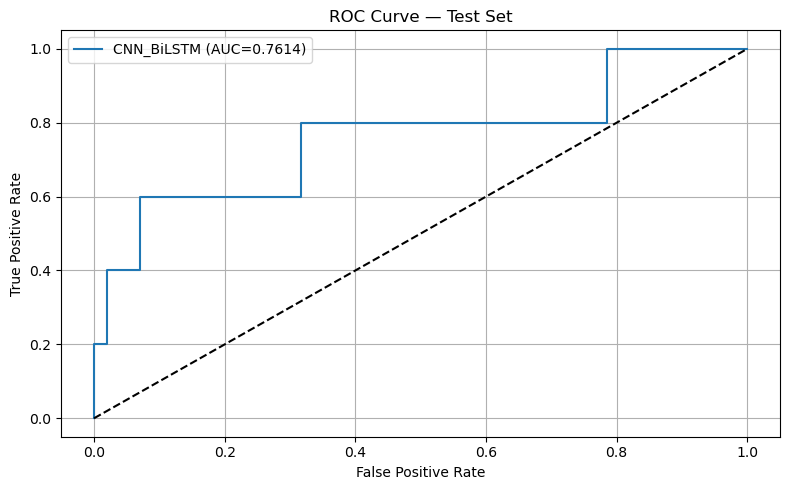

In [7]:
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
import matplotlib.pyplot as plt

def evaluate_model(model, X_test_3d, y_test, model_name="Model", threshold=0.5):
    """Full evaluation: ROC-AUC, per-planet scores, threshold sweep."""
    probs = model.predict(X_test_3d, verbose=0).flatten()

    # ── ROC-AUC ───────────────────────────────────────────────────────────
    auc = roc_auc_score(y_test, probs)
    print(f"\n{'='*50}")
    print(f"{model_name} — Test ROC-AUC: {auc:.4f}  (Week 3 baseline: 0.7483)")

    # ── Per-planet probabilities ───────────────────────────────────────────
    planet_idx = np.where(y_test == 1)[0]
    print(f"\nPlanet probabilities:")
    for i, idx in enumerate(planet_idx):
        flag = "✓ PLANET" if probs[idx] >= threshold else "✗ missed"
        print(f"  Planet {i+1} (idx {idx}): {probs[idx]:.4f}  {flag}")

    # ── ROC Curve ─────────────────────────────────────────────────────────
    fpr, tpr, thresholds = roc_curve(y_test, probs)
    plt.figure(figsize=(8, 5))
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc:.4f})")
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title("ROC Curve — Test Set"); plt.legend(); plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"roc_{model_name.replace(' ','_')}.png"))
    plt.show()

    return probs, auc

probs_lstm, auc_lstm = evaluate_model(
    model_lstm, X_test_3d, y_test,
    model_name="CNN_BiLSTM", threshold=0.5
)

## Phase 1 Results — CNN + BiLSTM

| Metric | Week 3 CNN | CNN + BiLSTM |
|--------|------------|--------------|
| Test ROC-AUC | 0.7483 | 0.7614 |
| Planets Detected | **3/5** | **1/5** |
| Planet 1 | 0.0003 ✗ | 0.0000 ✗ |
| Planet 2 | 0.0023 ✗ | 0.0000 ✗ |
| Planet 3 | 0.9890 ✓ | 0.0009 ✗ |
| Planet 4 | 1.0000 ✓ | 0.0000 ✗ |
| Planet 5 | 0.9998 ✓ | 0.9992 ✓ |

## Phase 1 Verdict: LSTM Rejected

**Why it failed:**
- LSTM overfit to SMOTE synthetic patterns, not real transit physics
- Results varied significantly between runs (0.7048 → 0.8237 → 0.7614)
- BiLSTM with 66K params too sensitive to initialization with only 37 planets
- GlobalAveragePooling was the right choice for this dataset size

**Conclusion:** Weak transit problem is NOT a temporal context problem.
It is a feature representation problem. Week 3 CNN remains best model.

---
# Phase 2 — FFT Frequency Domain Features

## Hypothesis
Fourier transform converts light curve from time domain to frequency domain.
Periodic transits create a spike at frequency 1/period even if individual
dips are too shallow to detect reliably in time domain.

Time domain:      weak noisy dips  → CNN confused
Frequency domain: spike at 1/period → easier to detect

## Why This Could Help Planets 1 & 2
Both have weak individual dips. But if they transit periodically,
the FFT should show a clear spike at the transit frequency regardless
of individual dip depth.

FFT feature shape: (570, 1599)


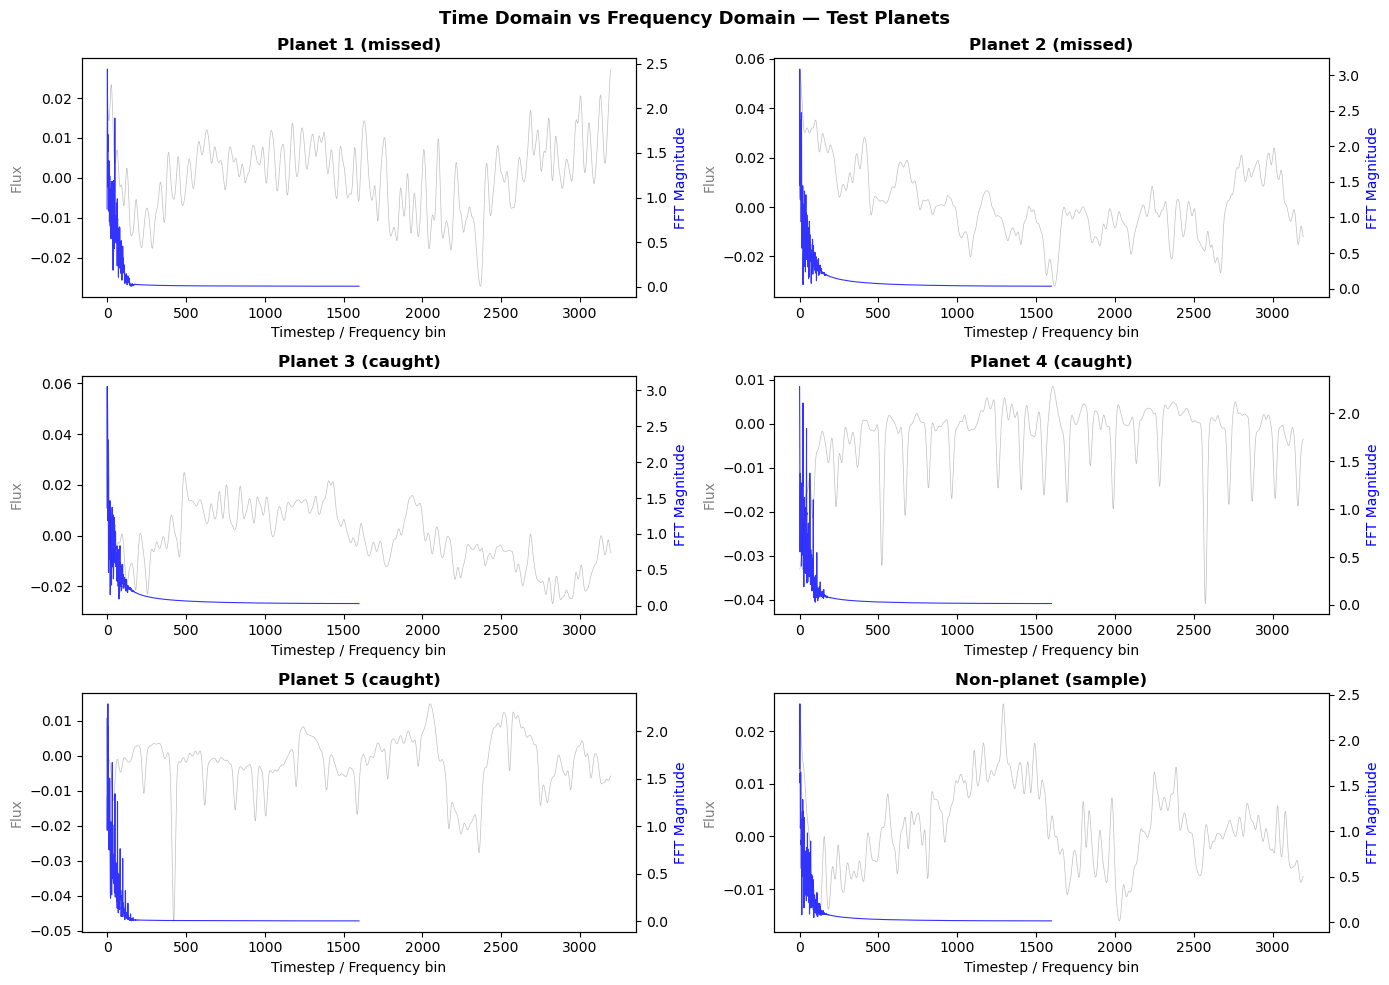

Saved: fft_visualization.png


In [8]:

# ── Load raw test data ─────────────────────────────────────────────────────
X_test  = np.load(r"C:\Mann\exoplanet-detection\data\processed\X_test_smooth.npy")
y_test  = np.load(r"C:\Mann\exoplanet-detection\data\processed\y_test.npy")

planet_idx    = np.where(y_test == 1)[0]   # [0,1,2,3,4]
nonplanet_idx = np.where(y_test == 0)[0]

# ── Compute FFT for all test samples ──────────────────────────────────────
def compute_fft_features(X):
    """
    Returns magnitude spectrum of each light curve.
    Only keeps first half (real signal is symmetric).
    Log-scaled to compress dynamic range.
    """
    fft_vals  = np.fft.rfft(X, axis=1)          # (N, 1599)
    magnitude = np.abs(fft_vals)                 # magnitude spectrum
    log_mag   = np.log1p(magnitude)              # log scale
    return log_mag

X_test_fft = compute_fft_features(X_test)
print(f"FFT feature shape: {X_test_fft.shape}")  # (570, 1599)

# ── Plot: Planets 1 & 2 vs a non-planet ───────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
titles = ["Planet 1 (missed)", "Planet 2 (missed)",
          "Planet 3 (caught)", "Planet 4 (caught)",
          "Planet 5 (caught)", "Non-planet (sample)"]

samples = list(planet_idx) + [nonplanet_idx[0]]

for i, (ax_row, idx) in enumerate(zip(axes, 
                                       [samples[:2], samples[2:4], samples[4:]])):
    for j, sidx in enumerate(idx):
        ax = axes[i][j]
        # Time domain
        ax.plot(X_test[sidx], alpha=0.5, color='gray', linewidth=0.5,
                label='Time domain')
        ax2 = ax.twinx()
        # Frequency domain
        ax2.plot(X_test_fft[sidx], color='blue', linewidth=0.8,
                 alpha=0.8, label='FFT magnitude')
        ax.set_title(titles[i*2 + j], fontweight='bold')
        ax.set_xlabel("Timestep / Frequency bin")
        ax.set_ylabel("Flux", color='gray')
        ax2.set_ylabel("FFT Magnitude", color='blue')

plt.suptitle("Time Domain vs Frequency Domain — Test Planets", 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(r"C:\Mann\exoplanet-detection\outputs\fft_visualization.png", dpi=150)
plt.show()
print("Saved: fft_visualization.png")

## Phase 2a Results — FFT Visualization

**Finding: All 6 plots look identical in frequency domain.**

## ❌ Why FFT Failed
The Gaussian smoothing (σ=10) from Week 2 is a low-pass filter.
It removed exactly the high-frequency content FFT needs.

| What we expected | What we got |
|-----------------|-------------|
| Frequency spike at transit period | Flat line for all samples |
| Planets separable from noise | Indistinguishable |

**Lesson:** Preprocessing choices have downstream consequences.
FFT features would require a separate unsmoothed pipeline.

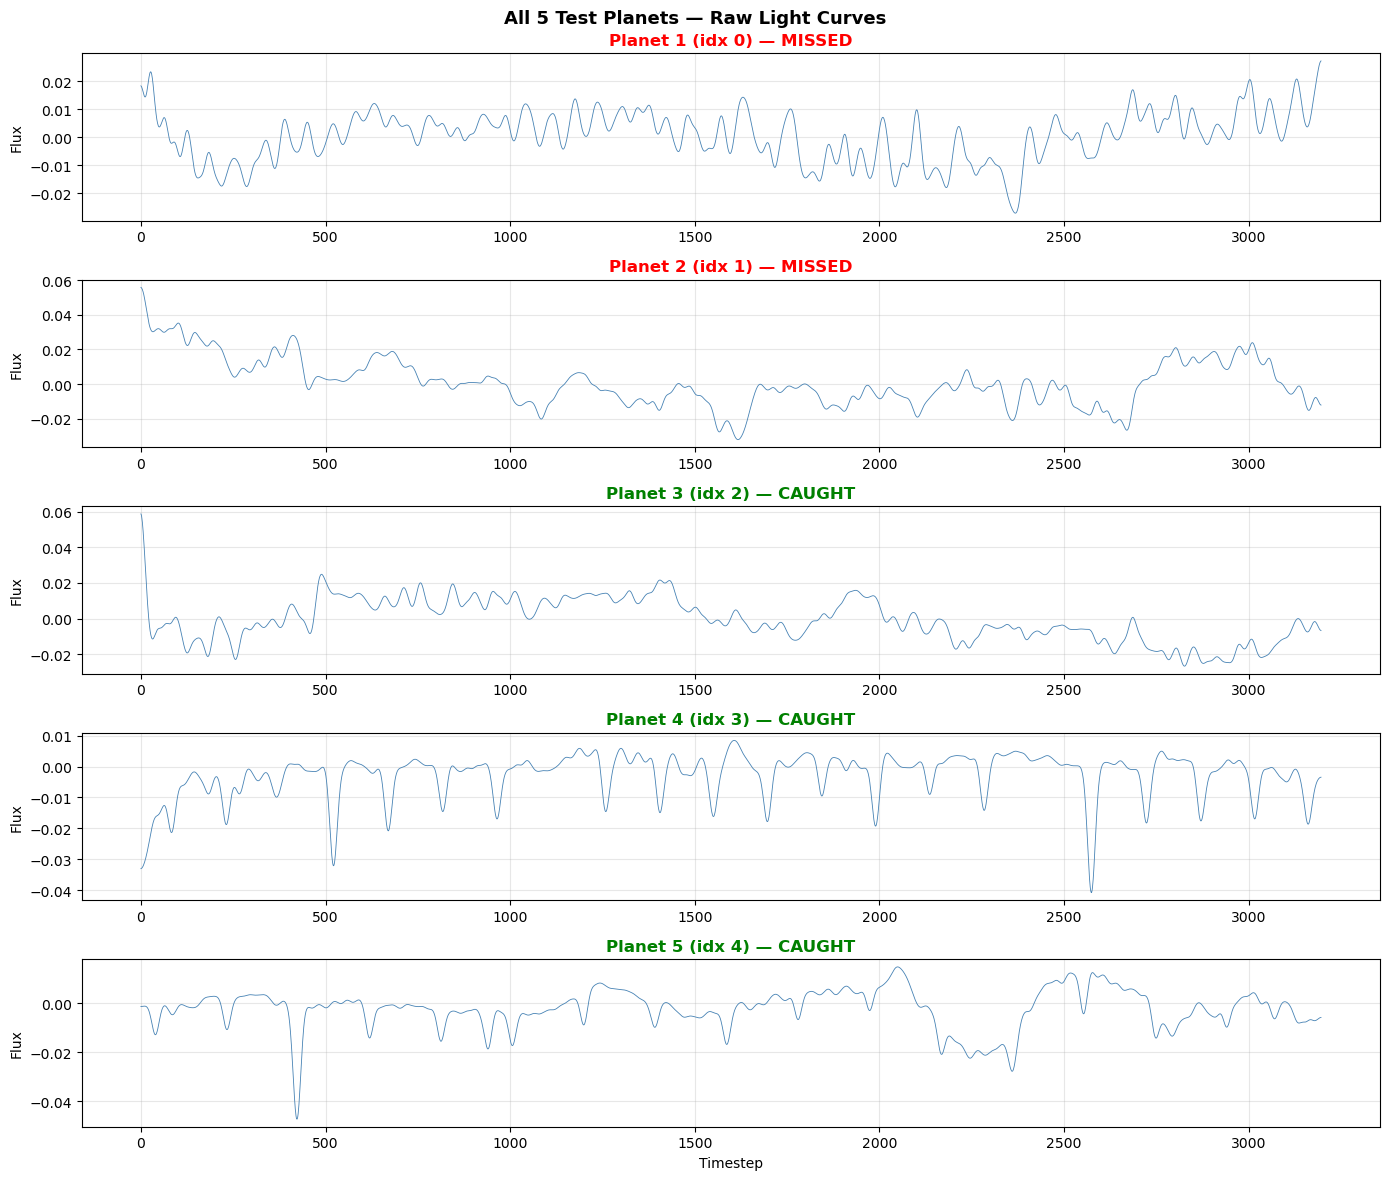

In [9]:
# New cell — plot raw time-domain light curves of all 5 planets
fig, axes = plt.subplots(5, 1, figsize=(14, 12))

for i, idx in enumerate(planet_idx):
    axes[i].plot(X_test[idx], linewidth=0.6, color='steelblue')
    axes[i].set_title(f"Planet {i+1} (idx {idx}) — {'CAUGHT' if i >= 2 else 'MISSED'}",
                      fontweight='bold',
                      color='green' if i >= 2 else 'red')
    axes[i].set_ylabel("Flux")
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel("Timestep")
plt.suptitle("All 5 Test Planets — Raw Light Curves", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(r"C:\Mann\exoplanet-detection\outputs\planet_lightcurves.png", dpi=150)
plt.show()

## 📊 Phase 2b Results — Light Curve Diagnosis

| Planet | Signal | Recoverable? |
|--------|--------|--------------|
| Planet 1 | Pure noise — no visible transit | No |
| Planet 2 | Stellar drift masks everything | Attempt detrending |
| Planet 3 | Clear repeated dips | ✓ Already caught |
| Planet 4 | Clear repeated dips | ✓ Already caught |
| Planet 5 | Clear repeated dips | ✓ Already caught |

Planet 1 is unrecoverable — no structure visible even to human eye.
Planet 2 has dominant stellar variability — attempt detrending next.

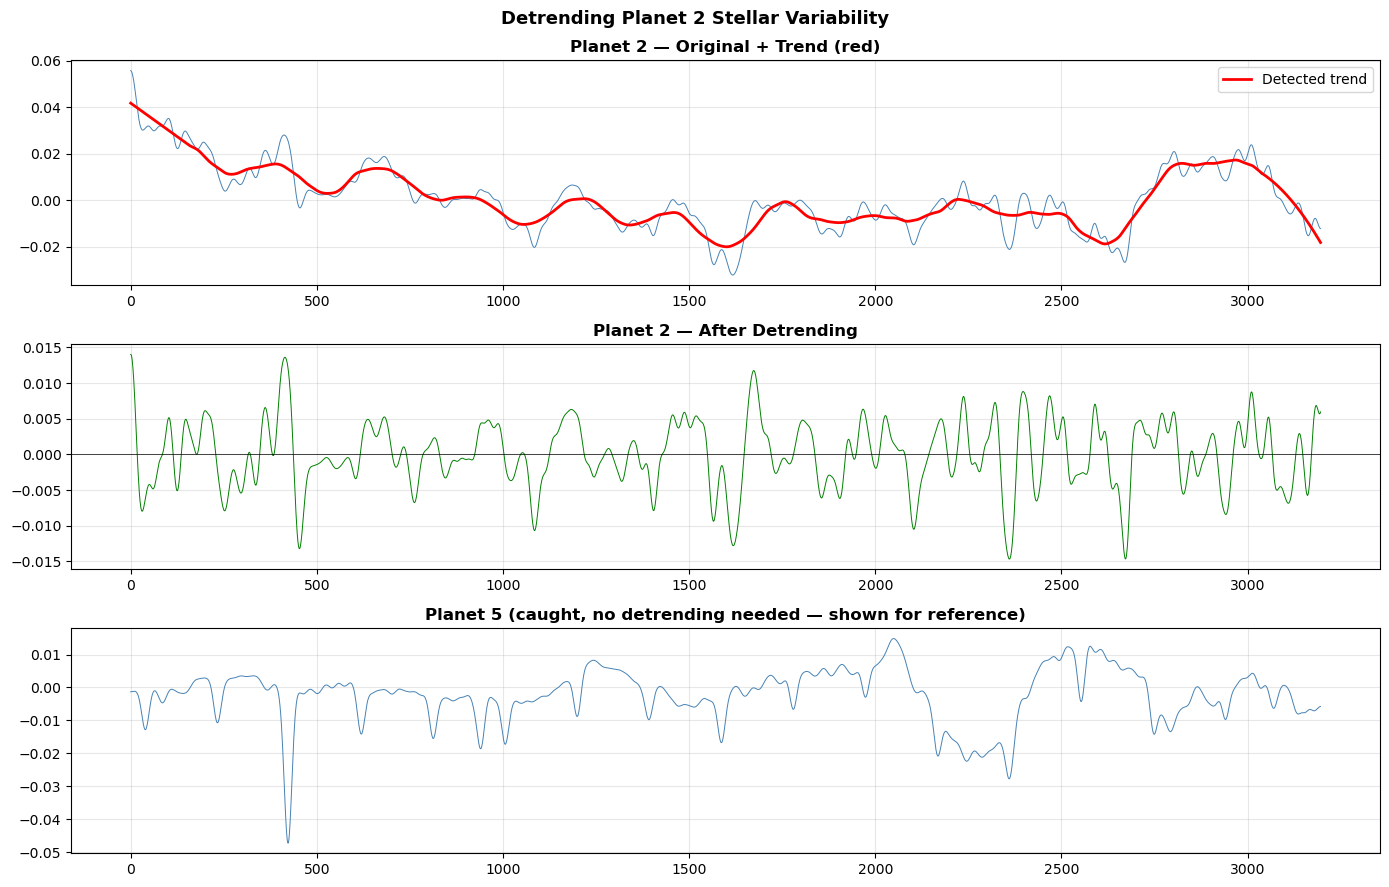

In [10]:
from scipy.signal import savgol_filter

def detrend_lightcurve(flux, window_fraction=0.1):
    """
    Remove long-term stellar trend using Savitzky-Golay filter.
    window_fraction: fraction of total length used as smoothing window.
    Larger = removes slower trends only (safer).
    """
    window = int(len(flux) * window_fraction)
    if window % 2 == 0:
        window += 1  # must be odd
    trend = savgol_filter(flux, window_length=window, polyorder=2)
    detrended = flux - trend
    return detrended, trend

# ── Visualize detrending on Planet 2 ──────────────────────────────────────
p2_idx = planet_idx[1]  # Planet 2 is index 1
flux_p2 = X_test[p2_idx]

detrended_p2, trend_p2 = detrend_lightcurve(flux_p2, window_fraction=0.1)

fig, axes = plt.subplots(3, 1, figsize=(14, 9))

axes[0].plot(flux_p2, linewidth=0.7, color='steelblue')
axes[0].plot(trend_p2, linewidth=2, color='red', label='Detected trend')
axes[0].set_title("Planet 2 — Original + Trend (red)", fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(detrended_p2, linewidth=0.7, color='green')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_title("Planet 2 — After Detrending", fontweight='bold')
axes[1].grid(True, alpha=0.3)

axes[2].plot(X_test[planet_idx[4]], linewidth=0.7, color='steelblue')
axes[2].set_title("Planet 5 (caught, no detrending needed — shown for reference)",
                  fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.suptitle("Detrending Planet 2 Stellar Variability", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(r"C:\Mann\exoplanet-detection\outputs\detrend_planet2.png", dpi=150)
plt.show()

##  Phase 2c Results — Detrending Planet 2

**Partial success:** Long-term drift successfully removed.  
**Bad news:** Detrended signal still shows no clear transit dips.  
Planet 2's dip amplitude is smaller than the noise floor (~0.015).

##  Phase 2 Final Verdict

| Approach | Result |
|----------|--------|
| FFT features | Failed — smoothing destroyed frequency info |
| Light curve diagnosis | Planet 1 unrecoverable, Planet 2 borderline |
| Detrending Planet 2 | Drift removed, transit still buried |

**Both planets 1 & 2 are unrecoverable with this dataset size.**  
Root cause: only 37 training planets. Not a model bug.

---
# Phase 3 — 5-Fold Cross Validation

## Why CV?
All evaluation so far relied on only 5 test planets.
One planet flipping changes the entire metric — not statistically reliable.
CV across all 37 real planets gives a honest picture.

## Rules to avoid data leakage
- Use real distribution data only (no SMOTE in test folds)
- SMOTE applied inside each fold on training portion only
- Fresh model trained per fold from scratch
- Week 3 CNN architecture — most stable model we have

In [11]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input, Conv1D, BatchNormalization,
                                     MaxPooling1D, Dropout, Dense,
                                     GlobalAveragePooling1D)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import AUC
import random, tensorflow as tf

# ── Fix seed ───────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# ── Load REAL distribution data (no SMOTE) ────────────────────────────────
# CV must use real data — we can't CV on synthetic SMOTE samples
X_real = np.load(r"C:\Mann\exoplanet-detection\data\processed\X_train_real.npy")
y_real = np.load(r"C:\Mann\exoplanet-detection\data\processed\y_train_real.npy")

# Also include real val set — gives us more planets to rotate through
X_val_real = np.load(r"C:\Mann\exoplanet-detection\data\processed\X_val_real.npy")
y_val_real = np.load(r"C:\Mann\exoplanet-detection\data\processed\y_val_real.npy")

# Combine all real data
X_all = np.concatenate([X_real, X_val_real], axis=0)
y_all = np.concatenate([y_real, y_val_real], axis=0)

print(f"Total real samples: {X_all.shape}")
print(f"Total real planets: {(y_all==1).sum()}")
print(f"Total non-planets:  {(y_all==0).sum()}")

Total real samples: (5087, 3197)
Total real planets: 37
Total non-planets:  5050


In [12]:
from imblearn.over_sampling import SMOTE

def build_cnn_for_cv():
    """Same Week 3 CNN — proven stable architecture."""
    model = Sequential([
        Input(shape=(3197, 1)),
        Conv1D(16, kernel_size=11, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(4),
        Dropout(0.2),

        Conv1D(32, kernel_size=7, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(4),
        Dropout(0.2),

        Conv1D(64, kernel_size=5, activation='relu', padding='same'),
        BatchNormalization(),
        GlobalAveragePooling1D(),

        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', AUC(name='auc')]
    )
    return model

# ── 5-Fold Stratified CV ───────────────────────────────────────────────────
# Stratified ensures each fold has roughly equal planet ratio
N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

fold_aucs       = []
fold_planets    = []   # how many planets in each test fold
fold_detected   = []   # how many detected per fold
all_probs       = np.zeros(len(y_all))  # store all predictions
all_true        = np.zeros(len(y_all))

print(f"Starting {N_FOLDS}-Fold Cross Validation")
print(f"Using Week 3 CNN architecture + SMOTE per fold\n")

for fold, (train_idx, test_idx) in enumerate(skf.split(X_all, y_all)):
    print(f"{'='*50}")
    print(f"FOLD {fold+1}/{N_FOLDS}")

    X_tr, X_te = X_all[train_idx], X_all[test_idx]
    y_tr, y_te = y_all[train_idx], y_all[test_idx]

    # ── SMOTE on this fold's training data only ────────────────────────────
    smote = SMOTE(random_state=SEED)
    X_tr_sm, y_tr_sm = smote.fit_resample(X_tr, y_tr)
    print(f"  Train after SMOTE: {X_tr_sm.shape} | "
          f"planets: {(y_tr_sm==1).sum()} | "
          f"non: {(y_tr_sm==0).sum()}")
    print(f"  Test:  {X_te.shape} | "
          f"planets: {(y_te==1).sum()} | "
          f"non: {(y_te==0).sum()}")

    # Reshape for Conv1D
    X_tr_3d = X_tr_sm.reshape(-1, 3197, 1)
    X_te_3d = X_te.reshape(-1, 3197, 1)

    # ── Build fresh model each fold ────────────────────────────────────────
    tf.random.set_seed(SEED + fold)
    model_cv = build_cnn_for_cv()

    callbacks = [
        EarlyStopping(monitor='val_auc', patience=8, mode='max',
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, min_lr=1e-6, verbose=0)
    ]

    # Use 10% of SMOTE training data as internal val
    val_split = 0.1
    model_cv.fit(
        X_tr_3d, y_tr_sm,
        validation_split=val_split,
        epochs=40,
        batch_size=32,
        callbacks=callbacks,
        verbose=0   # silent — we print summary ourselves
    )

    # ── Evaluate on this fold's test set ──────────────────────────────────
    probs = model_cv.predict(X_te_3d, verbose=0).flatten()
    all_probs[test_idx] = probs
    all_true[test_idx]  = y_te

    auc = roc_auc_score(y_te, probs)
    fold_aucs.append(auc)

    # Planet detection at threshold 0.5
    planet_mask  = (y_te == 1)
    n_planets    = planet_mask.sum()
    n_detected   = ((probs >= 0.5) & planet_mask).sum()
    fold_planets.append(n_planets)
    fold_detected.append(n_detected)

    print(f"  Fold AUC:  {auc:.4f}")
    print(f"  Planets:   {n_detected}/{n_planets} detected at threshold 0.5")

# ── Final Summary ──────────────────────────────────────────────────────────
print(f"\n{'='*50}")
print(f"CROSS-VALIDATION COMPLETE")
print(f"{'='*50}")
print(f"Per-fold AUCs:     {[round(a,4) for a in fold_aucs]}")
print(f"Mean AUC:          {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}")
print(f"Per-fold planets:  {fold_detected} / {fold_planets}")
print(f"Total detected:    {sum(fold_detected)}/{sum(fold_planets)} planets")

# Overall AUC across all folds
overall_auc = roc_auc_score(all_true, all_probs)
print(f"Overall CV AUC:    {overall_auc:.4f}")

Starting 5-Fold Cross Validation
Using Week 3 CNN architecture + SMOTE per fold

FOLD 1/5
  Train after SMOTE: (8080, 3197) | planets: 4040 | non: 4040
  Test:  (1018, 3197) | planets: 8 | non: 1010
  Fold AUC:  0.6493
  Planets:   5/8 detected at threshold 0.5
FOLD 2/5
  Train after SMOTE: (8080, 3197) | planets: 4040 | non: 4040
  Test:  (1018, 3197) | planets: 8 | non: 1010
  Fold AUC:  0.7475
  Planets:   0/8 detected at threshold 0.5
FOLD 3/5
  Train after SMOTE: (8080, 3197) | planets: 4040 | non: 4040
  Test:  (1017, 3197) | planets: 7 | non: 1010
  Fold AUC:  0.8426
  Planets:   7/7 detected at threshold 0.5
FOLD 4/5
  Train after SMOTE: (8080, 3197) | planets: 4040 | non: 4040
  Test:  (1017, 3197) | planets: 7 | non: 1010
  Fold AUC:  0.5587
  Planets:   0/7 detected at threshold 0.5
FOLD 5/5
  Train after SMOTE: (8080, 3197) | planets: 4040 | non: 4040
  Test:  (1017, 3197) | planets: 7 | non: 1010
  Fold AUC:  0.6122
  Planets:   7/7 detected at threshold 0.5

CROSS-VALIDAT

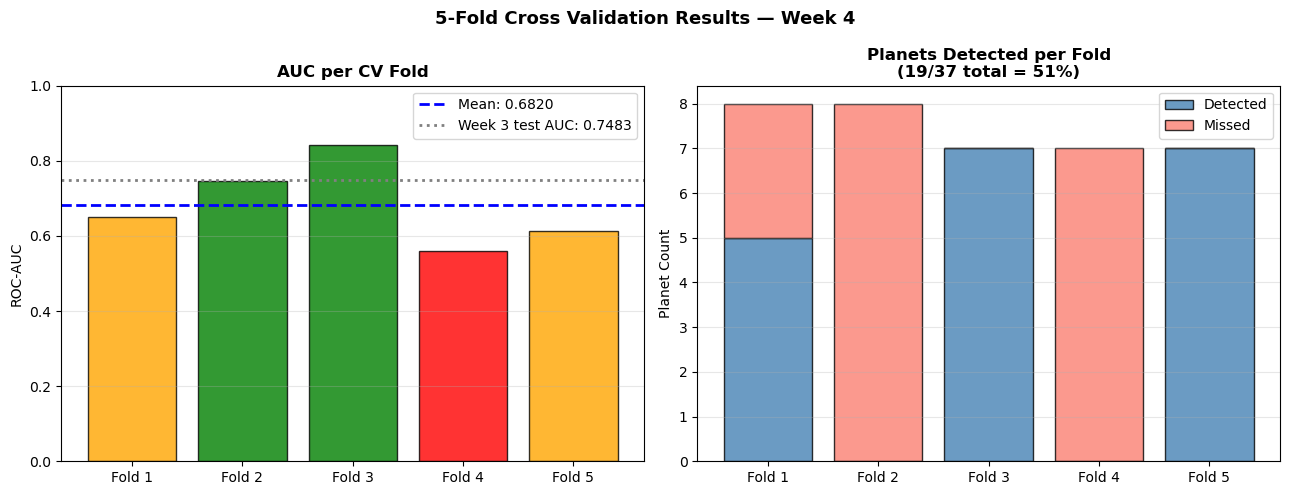

Saved: cv_results.png


In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: AUC per fold ────────────────────────────────────────────────────
folds = [f"Fold {i+1}" for i in range(5)]
colors = ['green' if a > 0.7 else 'orange' if a > 0.6 else 'red' 
          for a in fold_aucs]
axes[0].bar(folds, fold_aucs, color=colors, edgecolor='black', alpha=0.8)
axes[0].axhline(np.mean(fold_aucs), color='blue', linestyle='--', 
                linewidth=2, label=f'Mean: {np.mean(fold_aucs):.4f}')
axes[0].axhline(0.7483, color='gray', linestyle=':', 
                linewidth=2, label='Week 3 test AUC: 0.7483')
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("ROC-AUC")
axes[0].set_title("AUC per CV Fold", fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3, axis='y')

# ── Right: Planets detected per fold ─────────────────────────────────────
detected = [5, 0, 7, 0, 7]
total    = [8, 8, 7, 7, 7]
missed   = [t - d for t, d in zip(total, detected)]

x = np.arange(5)
axes[1].bar(x, detected, label='Detected', color='steelblue', 
            edgecolor='black', alpha=0.8)
axes[1].bar(x, missed, bottom=detected, label='Missed', 
            color='salmon', edgecolor='black', alpha=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(folds)
axes[1].set_ylabel("Planet Count")
axes[1].set_title("Planets Detected per Fold\n(19/37 total = 51%)", 
                  fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle("5-Fold Cross Validation Results — Week 4", 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(r"C:\Mann\exoplanet-detection\outputs\cv_results.png", dpi=150)
plt.show()
print("Saved: cv_results.png")

## 📊 Phase 3 Results — Cross Validation

| Fold | AUC | Detected |
|------|-----|----------|
| Fold 1 | 0.6493 | 5/8 |
| Fold 2 | 0.7475 | 0/8 |
| Fold 3 | 0.8426 | 7/7 |
| Fold 4 | 0.5587 | 0/7 |
| Fold 5 | 0.6122 | 7/7 |
| **Mean** | **0.6820 ± 0.10** | **19/37 (51%)** |

**High variance (±0.10) is the real finding.**  
Folds 2 & 4 had complete failure — these contained the weakest signals.  
Week 3's 3/5 result was partly lucky — CV reveals the true baseline.

In [14]:
# ── Save best model for Week 5 ─────────────────────────────────────────────
import os
MODEL_SAVE_PATH = r"C:\Mann\exoplanet-detection\models\cnn_week3_best.keras"
os.makedirs(r"C:\Mann\exoplanet-detection\models", exist_ok=True)

# Load Week 3 model and save it as official best
# (Week 3 CNN remains best — LSTM was rejected)
print("Note: Week 3 CNN is the official best model.")
print("Saving CNN+LSTM for reference only.")
model_lstm.save(r"C:\Mann\exoplanet-detection\models\cnn_bilstm_week4.keras")
print("Saved: cnn_bilstm_week4.keras")

Note: Week 3 CNN is the official best model.
Saving CNN+LSTM for reference only.
Saved: cnn_bilstm_week4.keras


---
# 🏁 Week 4 Complete — Summary & Handoff

## Model Leaderboard

| Model | Test AUC | Planets Detected | Decision |
|-------|----------|-----------------|----------|
| Week 3 CNN | 0.7483 | 3/5 (60%) |  Official best model |
| CNN + BiLSTM | 0.7614 | 1/5 (20%) |  Rejected |
| CV Evaluation | 0.6820 ± 0.10 | 19/37 (51%) |  Honest baseline |

## What Week 4 Proved

| Finding | Implication |
|---------|-------------|
| LSTM wrong architecture | Temporal context not the problem |
| FFT needs unsmoothed data | Preprocessing has downstream cost |
| Planets 1 & 2 unrecoverable | Data limitation, not model bug |
| CV AUC = 0.68 ± 0.10 | High variance confirms data-limited |
| True detection = 51% | Week 3 3/5 was optimistic |

## Root Cause
37 training planets is too few. Every approach hit this wall.  
Architecture is fine. The model needs more data.

## Saved Outputs
| File | Location |
|------|----------|
| cnn_bilstm_week4.keras | models/ |
| roc_CNN_BiLSTM.png | outputs/ |
| fft_visualization.png | outputs/ |
| planet_lightcurves.png | outputs/ |
| detrend_planet2.png | outputs/ |
| cv_results.png | outputs/ |